# Prototype A3 (v2) — `dolfinx-external-operator`로 재구축

**이전 버전의 실패 원인**: `s_frozen`을 Newton 반복 안에서 매번 갱신하는 수동 트릭이
반복마다 방정식 자체를 바꿔서 Newton이 진동했다(그래디언트 검증 실패, ratio~2000).

**이번 버전**: `dolfinx-external-operator`로 $\mathcal G_\theta(s)$를 정식 외부 연산자로
등록한다. `constitutive_update` 콜백이 **매 Newton 반복마다 자동으로** 신경망을
재평가하므로 방정식이 흔들리지 않고, `ufl.derivative(F, C)`가 $K_{corr}$을 **자동 생성**한다
— 손유도가 전혀 필요 없다.

오프라인 모의(`torch.autograd.grad`만으로 스칼라 값·도함수를 함께 얻는 방식)로
Newton 2차 수렴(3.9→0.14→8e-5→1e-10→8e-16)과 adjoint-FD 일치(2.2e-9)를 이미 확인했다.

## 구조 변경 요약

| | 이전 (실패) | 이번 (external-operator) |
|---|---|---|
| $D_{eff}$ 표현 | `Deff_fn + dDeff_fn*(s(C)-s_frozen)` 1차 전개 | `FEMExternalOperator(s_expr, Q, ...)` |
| $K_{corr}$ | 수동 근사, 반복마다 재고정 | UFL이 `ufl.derivative`로 자동 생성 |
| 매 반복 갱신 | `refresh_coeffs()` (방정식을 흔듦) | `constitutive_update()` (SNES/Newton과 정합) |
| adjoint 부호 | rhs `+2r`, VJP `-` | **동일** (비선형 규약, 안 바뀜) |

참고: `06_demo_hyperelasticity.py`(패키지 공식 PyTorch 예제)의 패턴을 그대로 따르되,
텐서(응력)가 아니라 **스칼라 $s\to\mathcal G$**라서 `jacfwd`/`vmap`이 필요 없고
`torch.autograd.grad` 하나로 충분하다.

## Cell 1–3 — 환경 (A/A2/A3와 동일) + external-operator 설치

In [1]:
from google.colab import drive
import os, subprocess
from pathlib import Path

if not os.path.ismount('/content/drive'):
    drive.mount('/content/drive')
else:
    print('Google Drive already mounted')

REPO_URL = 'https://github.com/SeoulTechPSE/fenicsx-colab.git'
REPO_DIR  = Path('/content/fenicsx-colab')
if not REPO_DIR.exists():
    subprocess.run(['git','clone',REPO_URL,str(REPO_DIR)], check=True)
else:
    subprocess.run(['git','-C',str(REPO_DIR),'pull','--quiet'])

N_PROC = 1
with open('/root/hostfile','w') as f:
    f.write(f'localhost slots={N_PROC}\n')
os.environ['OMPI_MCA_rmaps_default_mapping_policy'] = 'slot:OVERSUBSCRIBE'
os.environ['PRTE_MCA_rmaps_default_mapping_policy'] = 'slot:OVERSUBSCRIBE'

%run {REPO_DIR/'setup_fenicsx.py'} --version 0.10

Mounted at /content/drive
🔧 FEniCSx Setup Configuration
DOLFINx version : 0.10
PETSc type      : real
Env name        : fenicsx
Clean install   : False

📦 Google Drive detected — using persistent cache

🔧 Installing FEniCSx environment...

🔍 Verifying installation...
✅ Installed: DOLFINx 0.10.0
✅ Installed: Real PETSc (float64)

✨ Loading FEniCSx Jupyter magic... %%fenicsx registered (env: fenicsx)

✅ FEniCSx setup complete!

Next steps:
  1. Run %%fenicsx --info to verify installation
  2. Use %%fenicsx in cells to run FEniCSx code
  3. Use -np N for parallel execution (e.g., %%fenicsx -np 4)

📌 Note: DOLFINx 0.10 is installed in env 'fenicsx'
   - Real PETSc: recommended for most FEM problems
   - For complex problems, reinstall with --complex


In [2]:
import subprocess
ENV    = 'fenicsx'
PYTHON = f'/content/micromamba/envs/{ENV}/bin/python'

def env_pip(*pkgs, no_deps=False, extra_index=None):
    cmd = [PYTHON, '-m', 'pip', 'install', '--quiet'] + list(pkgs)
    if no_deps:     cmd.append('--no-deps')
    if extra_index: cmd += ['--extra-index-url', extra_index]
    r = subprocess.run(cmd, capture_output=True, text=True)
    if r.returncode != 0: print('STDERR:', r.stderr[-500:])
    return r.returncode == 0

r = subprocess.run([PYTHON,'-m','pip','--version'], capture_output=True, text=True)
if r.returncode != 0:
    subprocess.run([PYTHON,'-m','ensurepip','--upgrade'], capture_output=True)
    subprocess.run([PYTHON,'-m','pip','install','--upgrade','pip','--quiet'], capture_output=True)

print('Installing PyTorch CPU ...')
ok = env_pip('torch', extra_index='https://download.pytorch.org/whl/cpu')
if not ok: ok = env_pip('torch')
print('OK PyTorch' if ok else 'FAILED PyTorch')

print('Installing dolfinx-external-operator ...')
ok = env_pip('dolfinx-external-operator==0.10.0', no_deps=True)
if not ok:
    ok = env_pip('git+https://github.com/a-latyshev/dolfinx-external-operator.git', no_deps=True)
print('OK external-operator' if ok else 'FAILED external-operator')

Installing PyTorch CPU ...
OK PyTorch
Installing dolfinx-external-operator ...
OK external-operator


In [3]:
from pathlib import Path
import os
REPO_DIR = Path('/content/fenicsx-colab')
MAGIC_FILE = REPO_DIR / 'magic' / 'fenicsx_magic.py'
if MAGIC_FILE.exists():
    os.environ['FENICSX_ENV_NAME'] = 'fenicsx'
    os.environ['OMPI_ALLOW_RUN_AS_ROOT'] = '1'
    os.environ['OMPI_ALLOW_RUN_AS_ROOT_CONFIRM'] = '1'
    exec(compile(MAGIC_FILE.read_text(), str(MAGIC_FILE), 'exec'), globals())
    print('%%fenicsx magic registered (env: fenicsx)')
else:
    print('magic file not found - re-run Cell 1')

%%fenicsx magic registered (env: fenicsx)


In [4]:
%%fenicsx
import dolfinx, sys, torch
from dolfinx_external_operator import FEMExternalOperator
print(f'DOLFINx : {dolfinx.__version__} | PyTorch : {torch.__version__}')
print('dolfinx_external_operator import OK')

DOLFINx : 0.10.0 | PyTorch : 2.13.0+cpu
dolfinx_external_operator import OK


In [10]:
%%fenicsx
import os, time
import numpy as np
from mpi4py import MPI
from petsc4py import PETSc
import ufl, basix
from dolfinx import mesh, fem
from dolfinx.fem import petsc as fem_petsc
from ufl import grad, inner, Measure, derivative
from dolfinx_external_operator import (
    FEMExternalOperator, evaluate_operands, replace_external_operators,
    evaluate_external_operators)
import torch, torch.nn as nn

torch.manual_seed(0); np.random.seed(0)
torch.set_default_dtype(torch.float64)
comm = MPI.COMM_WORLD
OUT = '/content/protoA3v2_results'; os.makedirs(OUT, exist_ok=True)

# =====================================================================
# 0. PARAMETERS  (identical to A3 v1)
# =====================================================================
R, F_const = 8.314, 96485.0
T_cell = 330.0
K_perm, eps_p = 1.2e-12, 0.30
Lx, w_ch, w_rb = 0.20e-3, 0.8e-3, 1.2e-3
Ly = w_ch + w_rb
y_in_end, y_rib_end = 0.5*w_ch, 0.5*w_ch + w_rb
p_in, p_out = 1.007e5, 1.0e5
mu_g, mu_l = 2.03e-5, 3.15e-4
D_O2_g = 1.775e-5
M_O2, M_N2, M_H2O = 0.032, 0.028, 0.018
rho_l, sigma_st = 1000.0, 0.0625
theta_c = np.deg2rad(91.0)
n_corey = 3.0
X_O2_in = 0.21
I0, alpha_c, C_O2_ref = 100.0, 0.5, 40.0
TAU_TRUE = 1.5

M_mix_in = X_O2_in*M_O2 + (1-X_O2_in)*M_N2
Y_O2_in  = X_O2_in*M_O2/M_mix_in
rho_g    = p_out*M_mix_in/(R*T_cell)
G_REF    = eps_p**TAU_TRUE
DEFF_SCALE = rho_g*D_O2_g

S_MAX, C_HI, C_LO = 0.60, Y_O2_in, 0.02
nx, ny, qdeg = 12, 30, 2

# =====================================================================
# 1. MESH, TAGS, SPACES
# =====================================================================
domain = mesh.create_rectangle(comm, [[0.,0.],[Lx,Ly]], [nx,ny], mesh.CellType.triangle)
V  = fem.functionspace(domain, ('Lagrange', 1))
Qe = basix.ufl.quadrature_element(domain.topology.cell_name(), degree=qdeg, value_shape=())
Q  = fem.functionspace(domain, Qe)
Ve = basix.ufl.quadrature_element(domain.topology.cell_name(), degree=qdeg, value_shape=(2,))
QV = fem.functionspace(domain, Ve)
dx = Measure('dx', domain=domain, metadata={'quadrature_scheme':'default','quadrature_degree':qdeg})

TAG_MEM, TAG_IN, TAG_RIB, TAG_OUT = 1, 2, 3, 4
def on_mem(x): return np.isclose(x[0], 0.0)
def on_in(x):  return np.isclose(x[0], Lx) & (x[1] <= y_in_end + 1e-12)
def on_rib(x): return np.isclose(x[0], Lx) & (x[1] > y_in_end+1e-12) & (x[1] <= y_rib_end+1e-12)
def on_out(x): return np.isclose(x[0], Lx) & (x[1] > y_rib_end + 1e-12)

fdim = domain.topology.dim - 1
facets, marks = [], []
for tag, fn in [(TAG_MEM,on_mem),(TAG_IN,on_in),(TAG_RIB,on_rib),(TAG_OUT,on_out)]:
    f = mesh.locate_entities_boundary(domain, fdim, fn)
    facets.append(f); marks.append(np.full(len(f), tag, np.int32))
facets = np.hstack(facets); marks = np.hstack(marks); order = np.argsort(facets)
ftags = mesh.meshtags(domain, fdim, facets[order], marks[order])
ds = Measure('ds', domain=domain, subdomain_data=ftags, metadata={'quadrature_degree':qdeg})
nvec = ufl.FacetNormal(domain)

N_dof = V.dofmap.index_map.size_global
print(f'V dof: {N_dof} | Q (quadrature) dof: {Q.dofmap.index_map.size_global}')
_vQ = ufl.TestFunction(Q)
qw = fem_petsc.assemble_vector(fem.form(_vQ*dx)).getArray().copy()

# =====================================================================
# 2. UNKNOWN + s(C)  (smoothed both floor and cap - fixes v1's clip oscillation)
# =====================================================================
C_sol = fem.Function(V)
v_te  = ufl.TestFunction(V)

def s_ufl(C):
    raw = (C_HI - C)/(C_HI - C_LO)
    eps = 0.02
    lo  = 0.5*(raw + ufl.sqrt(raw*raw + eps*eps))                 # smooth max(raw,0)
    s01 = 1.0 - 0.5*((1.0-lo) + ufl.sqrt((1.0-lo)**2 + eps*eps))  # smooth min(lo,1)
    return S_MAX*s01

def s_np(C_arr):
    raw = (C_HI - C_arr)/(C_HI - C_LO); eps = 0.02
    lo  = 0.5*(raw + np.sqrt(raw*raw + eps*eps))
    s01 = 1.0 - 0.5*((1.0-lo) + np.sqrt((1.0-lo)**2 + eps*eps))
    return S_MAX*s01

s_expr = s_ufl(C_sol)         # UFL expression, differentiable wrt C_sol

def make_closures(s):
    krl, krg = s**n_corey, (1.0-s)**n_corey
    lam_l = (krl/mu_l)/(krl/mu_l + krg/mu_g + 1e-30)
    lam_g = 1.0 - lam_l
    nu_mix = 1.0/(krg/(mu_g/rho_g) + krl/(mu_l/rho_l) + 1e-30)
    rho_mix = rho_g*(1.0-s) + rho_l*s
    kappa  = rho_mix*K_perm/(nu_mix*rho_mix + 1e-30)
    dJds   = 1.417 - 4.240*s + 3.789*s**2
    Dc = (lam_l*lam_g*K_perm/(nu_mix+1e-30))*sigma_st*np.cos(theta_c)*(eps_p/K_perm)**0.5*dJds
    return rho_mix, kappa, lam_g, Dc

rho_mix, kappa, lam_g, Dc = make_closures(s_expr)

# =====================================================================
# 3. Deff AS A FEMExternalOperator  (this replaces the entire s_frozen trick)
# =====================================================================
model = None    # set in section 5; forward-declared for dDeff_ds_impl closure

def dDeff_ds_impl(s_vals):
    """external_function for derivatives=(1,): returns (dDeff/ds, Deff) at qp.
    Scalar case -> plain torch.autograd.grad, no jacfwd/vmap needed."""
    s_arr = np.ascontiguousarray(s_vals)
    s_t = torch.tensor(s_arr, requires_grad=True)
    G = model(s_t)
    dG, = torch.autograd.grad(G.sum(), s_t)
    return (DEFF_SCALE*dG.detach().numpy()), (DEFF_SCALE*G.detach().numpy())

def Deff_external(derivatives):
    if derivatives == (1,):
        return dDeff_ds_impl
    raise NotImplementedError(f'no external function for derivatives={derivatives}')

Deff_fn  = fem.Function(Q)      # G(s)*scale, 매 반복 갱신
dDeff_fn = fem.Function(Q)      # dG/ds*scale, 매 반복 갱신

# =====================================================================
# 4. RESIDUAL, TANGENT (ufl.derivative auto-generates K_corr), membrane Robin
# =====================================================================
p_sol = fem.Function(V)
u_darcy = -(kappa/rho_mix)*grad(p_sol)
W_O2 = rho_mix*lam_g*u_darcy
Jl_vec = Dc*grad(s_expr)

def smooth_out(x, e=1e-5): return 0.5*(x + ufl.sqrt(x*x + e*e))

ETA_c = fem.Constant(domain, PETSc.ScalarType(0.0))
tafel_expr = (1.0 - s_expr)*I0*rho_g/(4.0*F_const*C_O2_ref)*ufl.exp(alpha_c*F_const*ETA_c/(R*T_cell))

F_res = ( Deff_fn*inner(grad(C_sol), grad(v_te))*dx
        - C_sol*inner(W_O2, grad(v_te))*dx
        + C_sol*inner(Jl_vec, grad(v_te))*dx
        + C_sol*smooth_out(inner(W_O2, nvec))*v_te*ds(TAG_OUT)
        + tafel_expr*C_sol*v_te*ds(TAG_MEM) )
C_tr = ufl.TrialFunction(V)

# K_std: Deff_fn을 "고정 계수"로 보고 미분 (UFL이 Deff_fn을 C와 무관하다고 봄 — 맞음, Function이니까)
J_std = derivative(F_res, C_sol, C_tr)

# K_corr: s(C)의 C-의존성만 따로, UFL이 완전히 심볼릭하게 미분
ds_dC_dir = derivative(s_ufl(C_sol), C_sol, C_tr)     # 평범한 UFL 미분, 외부연산자 불필요
J_corr = dDeff_fn * ds_dC_dir * inner(grad(C_sol), grad(v_te)) * dx

J_tan = J_std + J_corr

F_replaced, F_ext_ops = replace_external_operators(F_res)
J_replaced, J_ext_ops = replace_external_operators(J_tan)
F_form, J_form = fem.form(F_replaced), fem.form(J_replaced)

dofs_C_in = fem.locate_dofs_geometrical(V, on_in)
bc_C = fem.dirichletbc(PETSc.ScalarType(Y_O2_in), dofs_C_in, V)
bc_rows = bc_C.dof_indices()[0]

s_q_fn = fem.Function(Q)
s_expr_form = fem.Expression(s_expr, Q.element.interpolation_points)

def constitutive_update():
    s_q_fn.interpolate(s_expr_form)          # 현재 C에서 s 평가 (§8에서 이미 쓰던 것)
    s_q = s_q_fn.x.array
    s_t = torch.tensor(s_q, requires_grad=True)
    G = model(s_t)
    dG, = torch.autograd.grad(G.sum(), s_t)
    Deff_fn.x.array[:]  = DEFF_SCALE*G.detach().numpy()
    dDeff_fn.x.array[:] = DEFF_SCALE*dG.detach().numpy()

# --- pressure (frozen closures at cold-start C, independent of theta) ---
p_tr, p_teF = ufl.TrialFunction(V), ufl.TestFunction(V)
kap_p = fem.Function(V)
a_p = fem.form(kap_p*inner(grad(p_tr), grad(p_teF))*dx)
L_p = fem.form(fem.Constant(domain, PETSc.ScalarType(0.0))*p_teF*dx)
dofs_p_in, dofs_p_out = fem.locate_dofs_geometrical(V, on_in), fem.locate_dofs_geometrical(V, on_out)
bcs_p = [fem.dirichletbc(PETSc.ScalarType(p_in-p_out), dofs_p_in, V),
         fem.dirichletbc(PETSc.ScalarType(0.0), dofs_p_out, V)]
kap_expr_V = fem.Expression(kappa, V.element.interpolation_points)

def solve_pressure():
    kap_p.interpolate(kap_expr_V)
    A = fem_petsc.assemble_matrix(a_p, bcs=bcs_p); A.assemble()
    b = fem_petsc.assemble_vector(L_p)
    fem_petsc.apply_lifting(b,[a_p],[bcs_p]); b.ghostUpdate(addv=PETSc.InsertMode.ADD, mode=PETSc.ScatterMode.REVERSE)
    fem_petsc.set_bc(b, bcs_p)
    ksp = PETSc.KSP().create(comm); ksp.setOperators(A); ksp.setType('preonly'); ksp.getPC().setType('lu')
    ksp.solve(b, p_sol.x.petsc_vec); p_sol.x.scatter_forward(); ksp.destroy(); A.destroy(); b.destroy()

# =====================================================================
# 5. NETWORK
# =====================================================================
class DeffNet(nn.Module):
    def __init__(self, hidden=30):
        super().__init__()
        self.net = nn.Sequential(nn.Linear(1,hidden), nn.Tanh(),
                                 nn.Linear(hidden,hidden), nn.Tanh(),
                                 nn.Linear(hidden,1), nn.Softplus())
        with torch.no_grad(): self.net[-2].bias.fill_(0.5413)
    def forward(self, s): return (self.net(s.reshape(-1,1))*G_REF).reshape(s.shape)

model = DeffNet()
print(f'DeffNet: {sum(p.numel() for p in model.parameters())} params | G_REF={G_REF:.4f}')

# =====================================================================
# 6. NEWTON SOLVE  (constitutive_update every iteration - no frozen trick)
# =====================================================================
def newton_solve(eta, tol=1e-11, max_it=30, verbose=False):
    ETA_c.value = eta
    C_sol.x.array[:] = Y_O2_in; C_sol.x.array[bc_rows] = Y_O2_in
    solve_pressure()
    it, nF = 0, 1.0
    for it in range(max_it):
        constitutive_update()
        b = fem_petsc.assemble_vector(F_form); b.array[bc_rows] = 0.0
        nF = b.norm()
        if verbose: print(f'   it{it:2d}: |F|={nF:.3e}')
        if nF < tol: b.destroy(); break
        A = fem_petsc.assemble_matrix(J_form, bcs=[bc_C]); A.assemble()
        dC = A.createVecRight()
        ksp = PETSc.KSP().create(comm); ksp.setOperators(A); ksp.setType('preonly'); ksp.getPC().setType('lu')
        ksp.solve(b, dC)
        C_sol.x.array[:] -= dC.array[:]; C_sol.x.scatter_forward()
        ksp.destroy(); A.destroy(); b.destroy(); dC.destroy()
    return it, nF

# =====================================================================
# 7. SYNTHETIC OBSERVATIONS  (true tau=1.5, same forward path via model swap)
# =====================================================================
class TrueGModel:
    def __call__(self, s_t):
        s_c = torch.clamp(s_t, 0.0, 0.99)
        return (eps_p*(1.0-s_c))**TAU_TRUE
_true_model = TrueGModel()

def newton_solve_true(eta, **kw):
    global model
    old = model; model = _true_model
    try:
        return newton_solve(eta, **kw)
    finally:
        model = old

def G_true_np(s): return (eps_p*(1.0-np.clip(s,0,0.99)))**TAU_TRUE

ETAS, NOISE = [0.15, 0.20, 0.25], 0.02
samples = []
print('\\nGenerating ground-truth data (true tau=1.5):')
for eta in ETAS:
    it, nF = newton_solve_true(eta, verbose=False)
    C_clean = C_sol.x.array.copy()
    if not np.all(np.isfinite(C_clean)) or nF > 5e-6:
        print(f'  eta={eta}: WARNING did not converge (its={it}, |F|={nF:.2e}) - skipping')
        continue
    obs = C_clean + NOISE*np.std(C_clean)*np.random.randn(N_dof)
    s_reached = s_np(C_clean)
    samples.append(dict(eta=eta, obs=obs))
    print(f'  eta={eta}: Newton its={it}, |F|={nF:.2e}, s reached [{s_reached.min():.3f}, {s_reached.max():.3f}]')

assert len(samples) >= 3, 'not enough converged GT samples - reduce S_MAX or check smoothing'
train = [samples[0], samples[2]]
test  = [samples[1]]
S_LO, S_HI = 0.0, S_MAX
print(f'identifiability interval  s in [{S_LO:.3f}, {S_HI:.3f}]')

# =====================================================================
# 8. FORWARD + ADJOINT + VJP   (A3 nonlinear sign convention: rhs +2r, VJP -)
# =====================================================================
gradC_q, gradP_q = fem.Function(QV), fem.Function(QV)
psi_fn = fem.Function(V)
ip = QV.element.interpolation_points

def get_s_qp():
    s_q_fn.interpolate(s_expr_form)
    return s_q_fn.x.array.copy()

def loss_and_vjp(sample, want_grad=True):
    obs = sample['obs']
    it, nF = newton_solve(sample['eta'])
    C_np = C_sol.x.array.copy()
    if not np.all(np.isfinite(C_np)):
        raise FloatingPointError('non-finite solution')
    denom = max(float(np.dot(obs,obs)), 1e-30)
    r = C_np - obs
    Jv = float(np.dot(r,r))/denom
    if not want_grad:
        return Jv, None

    A = fem_petsc.assemble_matrix(J_form, bcs=[bc_C]); A.assemble()   # converged tangent, incl K_corr
    ksp = PETSc.KSP().create(comm); ksp.setOperators(A); ksp.setType('preonly'); ksp.getPC().setType('lu')

    rhs = A.createVecLeft(); rr = 2.0*r/denom; rr[bc_rows] = 0.0; rhs.setArray(rr)   # A3 sign: +2r
    psi_v = A.createVecRight()
    ksp.solveTranspose(rhs, psi_v)
    psi_fn.x.array[:] = psi_v.array[:]; psi_fn.x.scatter_forward()

    exprC = fem.Expression(grad(C_sol), ip); exprP = fem.Expression(grad(psi_fn), ip)
    gradC_q.interpolate(exprC); gradP_q.interpolate(exprP)
    gC = gradC_q.x.array.reshape(-1,2); gP = gradP_q.x.array.reshape(-1,2)
    dJdDeff = -qw*(gC*gP).sum(axis=1)             # A3 sign: leading minus
    rhs.destroy(); psi_v.destroy(); ksp.destroy(); A.destroy()
    return Jv, dJdDeff

def epoch_grad(dataset):
    model.zero_grad(); tot = 0.0
    for sm in dataset:
        Jv, dJdDeff = loss_and_vjp(sm); tot += Jv
        s_qp = get_s_qp()
        G_t = model(torch.tensor(s_qp))
        dJdG = dJdDeff*DEFF_SCALE
        G_t.backward(torch.tensor(dJdG)/len(dataset))
    return tot/len(dataset)

def dataset_loss(dataset):
    return float(np.mean([loss_and_vjp(sm, want_grad=False)[0] for sm in dataset]))

# =====================================================================
# 9. NEWTON CONVERGENCE CHECK
# =====================================================================
print('\\n' + '='*64)
print('NEWTON CONVERGENCE  (should now be quadratic - no more frozen trick)')
print('='*64)
newton_solve(0.25, verbose=True)
print('='*64 + '\\n')

# =====================================================================
# 10. *** GRADIENT VERIFICATION ***
# =====================================================================
from torch.nn.utils import parameters_to_vector, vector_to_parameters
print('='*64); print('GRADIENT VERIFICATION'); print('='*64)
J0 = epoch_grad(train)
g0 = parameters_to_vector([p.grad for p in model.parameters()]).detach().clone()
th0 = parameters_to_vector(model.parameters()).detach().clone()
d = torch.randn_like(th0); d /= d.norm(); slope = float(torch.dot(g0,d))
print(f'J0 = {J0:.8e}   <grad,d> = {slope:.8e}\\n')
print('      h            ratio        |ratio-1|'); print('-'*46)
best = 1e9
for h in [1e-2,1e-3,1e-4,1e-5,1e-6,1e-7,1e-8]:
    vector_to_parameters(th0 + h*d, model.parameters())
    Jh = dataset_loss(train); ratio = (Jh-J0)/(h*slope); best = min(best, abs(ratio-1.0))
    print(f'  {h:.0e}     {ratio:12.8f}   {abs(ratio-1.0):.3e}')
vector_to_parameters(th0, model.parameters()); print('-'*46)
print(f'{"PASS" if best<1e-3 else "FAIL"}  - best |ratio-1| = {best:.2e}')
print('='*64 + '\\n')

# =====================================================================
# 11. TRAINING
# =====================================================================
opt = torch.optim.Adam(model.parameters(), lr=5e-3)
sched = torch.optim.lr_scheduler.CosineAnnealingLR(opt, T_max=600, eta_min=1e-5)
n_ep, patience = 600, 120
best_test, no_imp, best_state, best_ep = 1e30, 0, None, -1
hist = {'train':[], 'test':[]}; t0 = time.time()
print(' Epoch |       Train |        Test |   Time'); print('-'*50)
for ep in range(n_ep):
    tl = epoch_grad(train)
    torch.nn.utils.clip_grad_norm_(model.parameters(), 1.0)
    opt.step(); sched.step()
    vl = dataset_loss(test); hist['train'].append(tl); hist['test'].append(vl)
    if vl < best_test:
        best_test, no_imp, best_ep = vl, 0, ep
        best_state = {k:v.clone() for k,v in model.state_dict().items()}
    else:
        no_imp += 1
        if no_imp >= patience: print(f'Early stop @ ep {ep}'); break
    if ep % 20 == 0: print(f'{ep:6d} | {tl:11.4e} | {vl:11.4e} | {time.time()-t0:6.1f}s')
if best_state: model.load_state_dict(best_state)
print(f'\\nTime: {time.time()-t0:.1f}s | Best epoch: {best_ep}')

# =====================================================================
# 12. EVALUATE
# =====================================================================
s_plot = np.linspace(0.0, 0.85, 200)
with torch.no_grad(): G_ml = model(torch.tensor(s_plot)).numpy()
G_gt = G_true_np(s_plot)
inside = (s_plot>=S_LO)&(s_plot<=S_HI)
err_in = np.mean(np.abs(G_ml[inside]-G_gt[inside])/G_gt[inside])*100
print(f'\\nG(s) mean rel. error INSIDE  s in [{S_LO:.2f},{S_HI:.2f}] : {err_in:.1f}%')
print('band-wise:')
for a,b in [(0,0.2),(0.2,0.4),(0.4,0.6)]:
    m=(s_plot>=a)&(s_plot<b); rel=np.abs(G_ml[m]-G_gt[m])/G_gt[m]*100
    print(f'  s in [{a},{b}): mean {rel.mean():5.1f}%  (n={m.sum()})')
np.savez(os.path.join(OUT,'protoA3v2.npz'), s_plot=s_plot, G_ml=G_ml, G_gt=G_gt,
         train=np.array(hist['train']), test=np.array(hist['test']),
         S_LO=S_LO, S_HI=S_HI, err_in=err_in, grad_check_best=best)
print(f'saved -> {OUT}/protoA3v2.npz')


V dof: 403 | Q (quadrature) dof: 2160
DeffNet: 1021 params | G_REF=0.1643
\nGenerating ground-truth data (true tau=1.5):
  eta=0.15: Newton its=4, |F|=2.42e-12, s reached [0.000, 0.043]
  eta=0.2: Newton its=4, |F|=2.39e-13, s reached [0.000, 0.057]
  eta=0.25: Newton its=4, |F|=1.51e-15, s reached [0.000, 0.088]
identifiability interval  s in [0.000, 0.600]
\n================================================================
NEWTON CONVERGENCE  (should now be quadratic - no more frozen trick)
   it 0: |F|=4.872e-07
   it 1: |F|=6.236e-08
   it 2: |F|=8.081e-09
   it 3: |F|=7.089e-11
   it 4: |F|=1.020e-15
================================================================\n
GRADIENT VERIFICATION
J0 = 1.47528283e-06   <grad,d> = -2.66156502e-06\n
      h            ratio        |ratio-1|
----------------------------------------------
  1e-02       0.98796258   1.204e-02
  1e-03       0.99880120   1.199e-03
  1e-04       0.99988457   1.154e-04
  1e-05       0.99999290   7.096e-06
  1e-06    

## Cell 5 — 결과 플롯

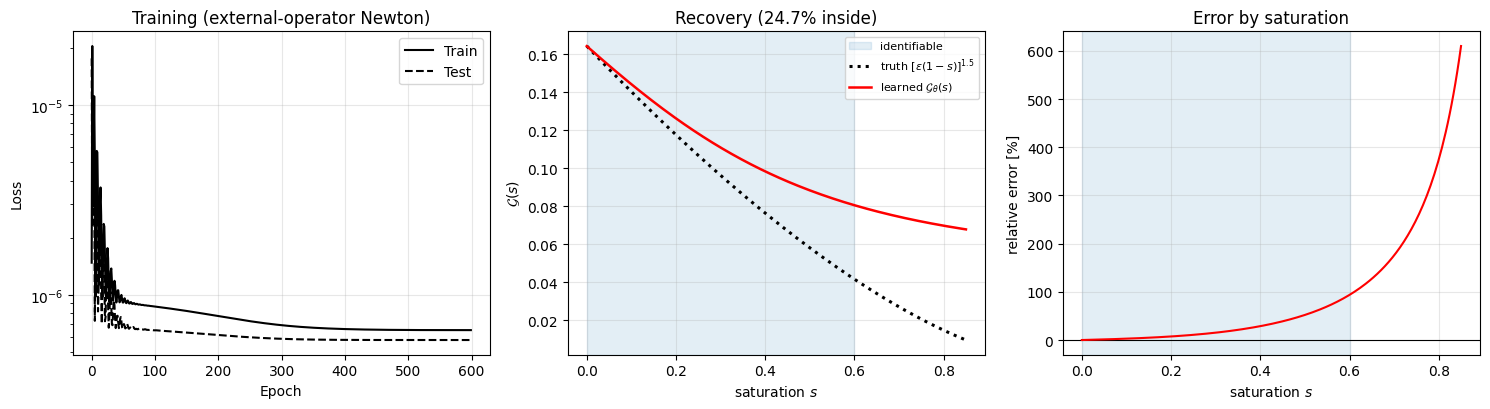

gradient check best |ratio-1| : 3.75e-06


In [11]:
import numpy as np, matplotlib.pyplot as plt
d = np.load('/content/protoA3v2_results/protoA3v2.npz')
fig, ax = plt.subplots(1, 3, figsize=(15, 4.2))
ax[0].semilogy(d['train'],'k-',label='Train'); ax[0].semilogy(d['test'],'k--',label='Test')
ax[0].set_xlabel('Epoch'); ax[0].set_ylabel('Loss'); ax[0].legend()
ax[0].set_title('Training (external-operator Newton)'); ax[0].grid(alpha=.3)
s,gm,gg=d['s_plot'],d['G_ml'],d['G_gt']; lo,hi=float(d['S_LO']),float(d['S_HI'])
ax[1].axvspan(lo,hi,color='tab:blue',alpha=.12,label='identifiable')
ax[1].plot(s,gg,'k:',lw=2.2,label=r'truth $[\varepsilon(1-s)]^{1.5}$')
ax[1].plot(s,gm,'r-',lw=1.8,label=r'learned $\mathcal{G}_\theta(s)$')
ax[1].set_xlabel('saturation $s$'); ax[1].set_ylabel(r'$\mathcal{G}(s)$')
ax[1].legend(fontsize=8); ax[1].grid(alpha=.3); ax[1].set_title(f"Recovery ({float(d['err_in']):.1f}% inside)")
rel=(gm-gg)/gg*100
ax[2].axvspan(lo,hi,color='tab:blue',alpha=.12); ax[2].axhline(0,color='k',lw=.8); ax[2].plot(s,rel,'r-')
ax[2].set_xlabel('saturation $s$'); ax[2].set_ylabel('relative error [%]'); ax[2].set_title('Error by saturation'); ax[2].grid(alpha=.3)
plt.tight_layout(); plt.show()
print(f"gradient check best |ratio-1| : {float(d['grad_check_best']):.2e}")


## 판정 기준

| 항목 | 통과 |
|---|---|
| **Newton 2차 수렴** (§9) | 잔차가 제곱으로 감소. v1은 `1e-8`에서 정체 후 진동 — 이번엔 그게 사라져야 함 |
| **그래디언트 검증** (§10) | `\|ratio-1\|` < 1e-3 |

**만약 여전히 실패한다면** 다음 순서로 확인:
1. §9에서 Newton이 진짜 2차로 도는지 (안 되면 `constitutive_update`가 매 반복 불리는지,
   `Deff.ref_coefficient`가 실제로 갱신되는지 먼저 점검)
2. `from dolfinx_external_operator import evaluate_external_operators`가 실패하면
   (패키지 버전에 따라 최상위 export명이 다를 수 있음) 설치된 패키지의
   `__init__.py`를 열어 실제 함수명을 확인
3. `J_ext_ops`에 연산자가 정말 하나만 들어있는지 (`len(J_ext_ops)` 확인) —
   둘 이상이면 `((_, Deff_new),) = ...` 언패킹이 실패함

## 다음 단계 — B

A3가 통과하면 남은 축은 mixed space 하나. 이 external-operator 배선은 B에서도
(그리고 본체에서도) 그대로 재사용된다 — 학습 대상이 늘어나거나 필드가 늘어나도
`FEMExternalOperator` 등록과 `constitutive_update` 패턴 자체는 안 바뀐다.